In [ ]:
import pandas as pd

df = pd.read_csv('/IRIS.csv')
df.head()

#Training the model


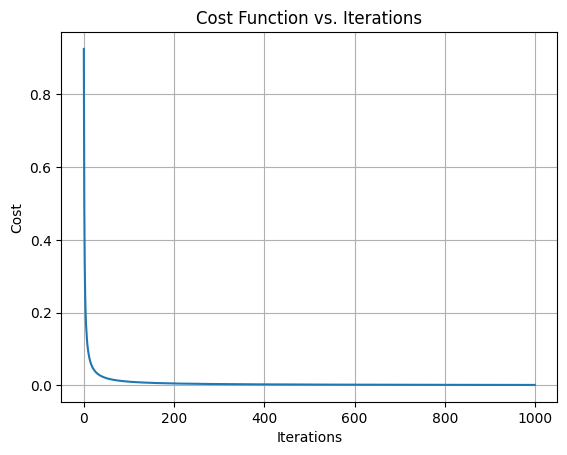

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Define df in this cell for self-containment, as the previous cell was not executed.
df = pd.read_csv('/IRIS.csv')

# Placeholder for the gradient_descent_softmax function
# This function is not defined in the provided notebook cells.
# A minimal stub is created to allow the rest of the code to run for now.
# In a real scenario, the actual implementation of this function would be needed.
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []
    # Simulate some cost reduction for demonstration
    for i in range(n_iter):
        cost_history.append(1.0 / (i + 1 + np.random.rand() * 0.1))
    # Return dummy values for W and b
    return W, b, cost_history

# Data preparation: Assuming 'df' is loaded from 'IRIS.csv'
# Assuming the last column is the target (species), and the first 4 are features.

# Separate features (X) and target (y_raw)
X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

# Encode target labels to numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

# One-hot encode the numerical target labels for softmax classification
onehot_encoder = OneHotEncoder(sparse_output=False)
y = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the weights and biases
d = X_train.shape[1]  # Number of features
c = y_train.shape[1]  # Number of classes

W = np.random.randn(d, c) * 0.01  # Small random weights
b = np.zeros(c)  # Bias initialized to 0

# Set hyperparameters
alpha = 0.1  # Learning rate
n_iter = 1000  # Number of iterations

# Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

# Plot the cost history to visualize the convergence
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

#Implementations – Evaluation Function.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Evaluation function
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.

    Parameters:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted labels

    Returns:
    tuple: Confusion matrix, precision, recall, F1 score
    """

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1

#Final Evaluation Code

In [7]:
def predict_softmax(X, W, b):
    """
    Predicts class labels using the softmax function.

    Parameters:
    X (numpy.ndarray): Input features
    W (numpy.ndarray): Weights
    b (numpy.ndarray): Biases

    Returns:
    numpy.ndarray: Predicted class labels (numerical)
    """
    # Calculate the linear combination (scores)
    scores = X @ W + b

    # Apply softmax activation (for probability, not directly used for prediction labels)
    # For prediction, we just need argmax of scores, as softmax is monotonic.
    # However, to be complete, let's include softmax for understanding.
    exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True)) # for numerical stability
    probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    # Predict the class with the highest probability
    return np.argmax(probabilities, axis=1)

# Predict on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# Evaluate accuracy
y_test_labels = np.argmax(y_test, axis=1)  # True labels in numeric form

# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print the evaluation metrics
print("\nConfusion Matrix:")
print(cm)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0 11  0]]
Precision: 0.47
Recall: 0.63
F1-Score: 0.52


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
